<a href="https://colab.research.google.com/github/KAyush16/PyLibra/blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Using Data - Generation:

Data generators are used to load data in batches without consuming large memory.


In [ ]:
! mkdir -p ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:08<00:00, 137MB/s]



In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [11]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten

from keras.applications.vgg16 import VGG16
from keras.applications.mobilenet import MobileNet

In [14]:
conv_base = MobileNet(
    include_top = False, # FC layer --> it donot include it
    weights = 'imagenet',
    input_shape = (128,128,3)
)
# it will only include the Convolution Layer

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
conv_base.summary()

Model: "mobilenet_1.00_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 64, 64, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 65, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 32, 32, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 32, 32, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 32, 32, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 32, 32, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,228,864 (12.32 MB)

 Trainable params: 3,206,976 (12.23 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [16]:
# trian the FC layer
model = Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_128 (Functional) │ (None, 4, 4, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,423,681 (28.32 MB)

 Trainable params: 7,401,793 (28.24 MB)

 Non-trainable params: 21,888 (85.50 KB)

#### If we dont do `conv_base.trainable = False` then it will train the convolution layer --> Transfer Learning again

In [17]:
conv_base.trainable = False

In [18]:
# Pre process the data
# use generators

train_ds = keras.utils.image_dataset_from_directory(
    '/content/train',
    labels='inferred',
    batch_size=16,
    image_size=(128,128)
)

train_ds = train_ds.take(40)

test_ds = keras.utils.image_dataset_from_directory(
    '/content/test',
    labels='inferred',
    batch_size=16,
    image_size=(128,128)
)

test_ds = test_ds.take(20)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [19]:
# normalize the data
def process(image,label):
  image = tensorflow.cast(image/255. ,tensorflow.float32)
  return image,label

train_ds = train_ds.map(process)
test_ds = test_ds.map(process)

In [20]:
model.compile(optimizer = 'adam',loss = 'binary_crossentropy',metrics = ['accuracy'])

In [21]:
history = model.fit(train_ds,epochs=10,validation_data=test_ds)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 583ms/step - accuracy: 0.9141 - loss: 0.7595 - val_accuracy: 0.9187 - val_loss: 0.5973
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 419ms/step - accuracy: 0.9797 - loss: 0.1140 - val_accuracy: 0.9469 - val_loss: 0.3426
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 650ms/step - accuracy: 0.9875 - loss: 0.0557 - val_accuracy: 0.9688 - val_loss: 0.3225
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 494ms/step - accuracy: 0.9875 - loss: 0.0941 - val_accuracy: 0.9656 - val_loss: 0.3302
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 512ms/step - accuracy: 0.9891 - loss: 0.0948 - val_accuracy: 0.9594 - val_loss: 0.4362
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 566ms/step - accuracy: 0.9953 - loss: 0.0562 - val_accuracy: 0.9438 - val_loss: 0.4705
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 420ms/step - accuracy: 0.9922 - loss: 0.0527 - val_accuracy: 0.9531 - val_loss: 0.4750
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 646ms/step - accuracy: 0.9984 - loss: 0.0032 - val_accu

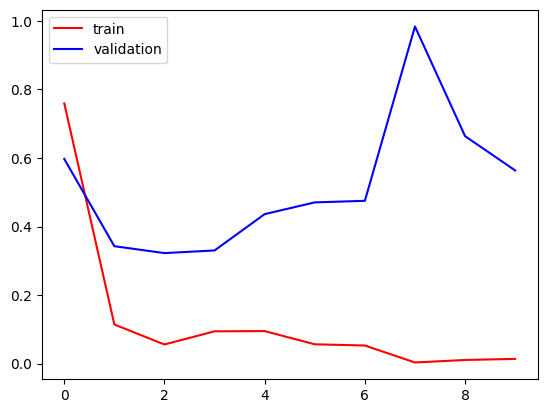

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

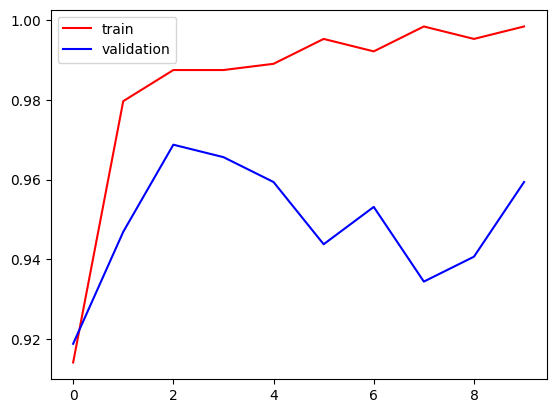

In [23]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

# Using Data Augmentation
Data augmentation is used to create transformed versions of existing data to improve generalization and reduce overfitting.

In [34]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten
from keras.applications.vgg16 import VGG16
from keras.applications.mobilenet import MobileNet

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [40]:
conv_base = MobileNet(
    weights = 'imagenet',
    include_top = False,
    input_shape = (96,96,3)
)
conv_base.trainable = False

/tmp/ipykernel_21639/2674473800.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  conv_base = MobileNet(


In [41]:
conv_base.output.shape

(None, 3, 3, 1024)

In [42]:
# FC layer
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 3, 3, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,588,673 (21.32 MB)

 Trainable params: 2,359,809 (9.00 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

#### Data Augmentation


In [43]:
batch_size = 8

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

test_datagen = ImageDataGenerator(
    rescale = 1./255
)

train_generator = train_datagen.flow_from_directory(
    '/content/train',
    target_size = (96,96),
    batch_size = batch_size,
    class_mode = 'binary'
)

test_generator = test_datagen.flow_from_directory(
    '/content/test',
    target_size = (96,96),
    batch_size = batch_size,
    class_mode = 'binary'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [44]:
model.compile(optimizer = 'adam',loss = 'binary_crossentropy',metrics = ['accuracy'])

In [47]:
history = model.fit(
    train_generator,
    steps_per_epoch = 30,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8667 - loss: 0.5325 - val_accuracy: 0.8922 - val_loss: 0.4385
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.8917 - loss: 0.5104 - val_accuracy: 0.9168 - val_loss: 0.3221
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.9125 - loss: 0.4095 - val_accuracy: 0.9132 - val_loss: 0.3651
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.8750 - loss: 0.5581 - val_accuracy: 0.9092 - val_loss: 0.3495
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.8958 - loss: 0.4165 - val_accuracy: 0.9068 - val_loss: 0.3340
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.8750 - loss: 0.3435 - val_accuracy: 0.9186 - val_loss: 0.2649
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.9000 - loss: 0.3435 - val_accuracy: 0.9102 - val_loss: 0.3261
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9083 - loss: 0.2978 - val_accuracy: 0.8982 - val_loss:

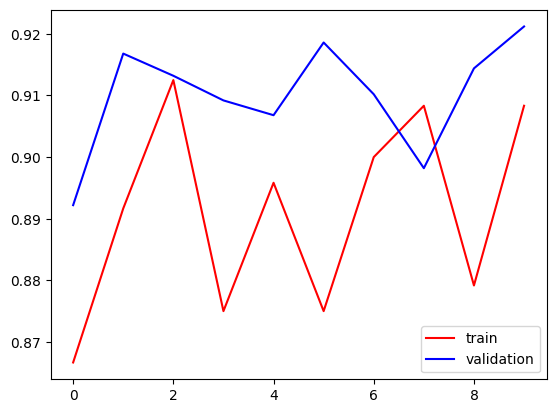

In [48]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

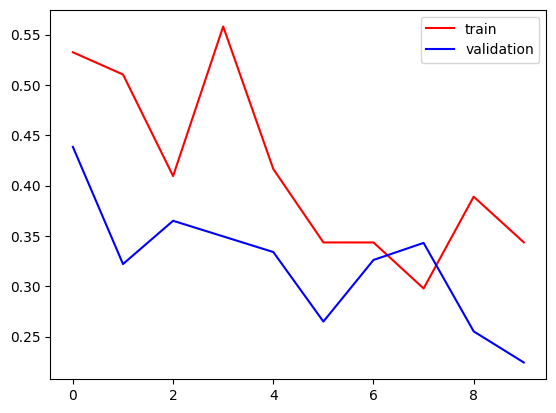

In [49]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

# In Convolution Layer --> divide training  : train only Last conv_layer  and above part dont train. With FC layer training too

In [50]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16
from keras.applications.mobilenet import MobileNet

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape = (150,150,3)
)

conv_base.trainable = True

set_trainable = False

for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False
for layer in conv_base.layers:
  print(layer.name, layer.trainable)

In [ ]:
conv_base.summary()

In [ ]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

In [ ]:
# use generators to train the data in the batches
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',
    label_mode ='int',
    batch_size = 32,
    image_size = (150,150)
)

In [ ]:
test_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',
    label_mode ='int',
    batch_size = 32,
    image_size = (150,150)

)

In [ ]:
# normalize the data
def process(image,label):
  image = tensorflow.cast(image/255. ,tensorflow.float32)
  return image,label

train_ds = train_ds.map(process)
test_ds = test_ds.map(process)

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
history = model.fit(train_ds,epochs=10,validation_data=test_ds)

In [ ]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

/tmp/ipykernel_38736/4143006322.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  conv_base = MobileNet(


conv_pw_10_relu False
conv_dw_11 False
conv_dw_11_bn False
conv_dw_11_relu False
conv_pw_11 False
conv_pw_11_bn False
conv_pw_11_relu True
conv_pad_12 True
conv_dw_12 True
conv_dw_12_bn True
conv_dw_12_relu True
conv_pw_12 True
conv_pw_12_bn True
conv_pw_12_relu True
conv_dw_13 True
conv_dw_13_bn True
conv_dw_13_relu True
conv_pw_13 True
conv_pw_13_bn True
conv_pw_13_relu True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 3, 3, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,491,521 (13.32 MB)

 Trainable params: 1,856,513 (7.08 MB)

 Non-trainable params: 1,635,008 (6.24 MB)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 226ms/step - accuracy: 0.4917 - loss: 1.2214 - val_accuracy: 0.5125 - val_loss: 1.5194
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.5458 - loss: 0.8636 - val_accuracy: 0.6500 - val_loss: 0.9155
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.6667 - loss: 0.5998 - val_accuracy: 0.7500 - val_loss: 0.5466
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step - accuracy: 0.7375 - loss: 0.5096 - val_accuracy: 0.8250 - val_loss: 0.4709
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.7792 - loss: 0.4777 - val_accuracy: 0.8000 - val_loss: 0.4182


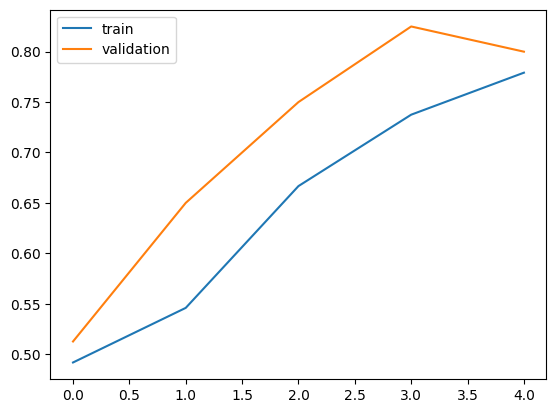

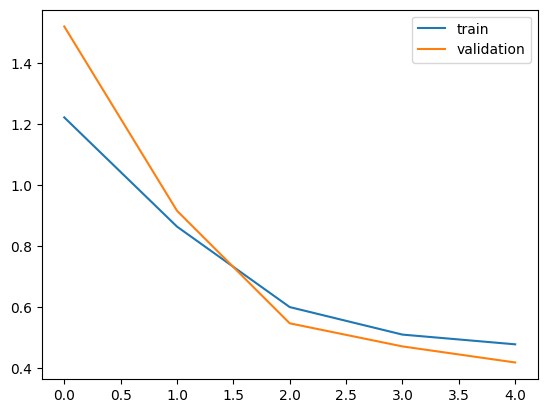

In [1]:
# ==========================================
# IMPORTS
# ==========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


# ==========================================
# LOAD PRETRAINED MODEL
# ==========================================
conv_base = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)


# ==========================================
# FINE TUNING
# Freeze all layers except last few
# ==========================================
conv_base.trainable = True

set_trainable = False

for layer in conv_base.layers:

    if layer.name == 'conv_pw_11_relu':
        set_trainable = True

    layer.trainable = set_trainable


# check trainable layers
for layer in conv_base.layers[-20:]:
    print(layer.name, layer.trainable)


# ==========================================
# BUILD MODEL
# ==========================================
model = Sequential()

model.add(conv_base)

model.add(GlobalAveragePooling2D())

model.add(Dense(256,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

model.summary()


# ==========================================
# LOAD DATA
# ==========================================
batch_size = 8

train_ds = keras.utils.image_dataset_from_directory(
    '/content/train',
    labels='inferred',
    batch_size=batch_size,
    image_size=(96,96),
    shuffle=True
)

test_ds = keras.utils.image_dataset_from_directory(
    '/content/test',
    labels='inferred',
    batch_size=batch_size,
    image_size=(96,96)
)


# ==========================================
# USE SMALL DATASET
# ==========================================
train_ds = train_ds.take(30)
test_ds = test_ds.take(10)


# ==========================================
# PREPROCESSING
# ==========================================
def process(image,label):

    image = tf.cast(image,tf.float32)

    image = tf.keras.applications.mobilenet.preprocess_input(
        image
    )

    return image,label


train_ds = train_ds.map(process)
test_ds = test_ds.map(process)


# ==========================================
# SPEEDUP
# ==========================================
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


# ==========================================
# COMPILE
# ==========================================
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# ==========================================
# TRAIN
# ==========================================
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)


# ==========================================
# ACCURACY PLOT
# ==========================================
plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='validation'
)

plt.legend()
plt.show()


# ==========================================
# LOSS PLOT
# ==========================================
plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='validation'
)

plt.legend()
plt.show()